# Ερώτημα 3 - Clustering (CIC-IDS-2017)

**Στόχοι αυτού του notebook**

1. Φόρτωση του καθαρού, feature-selected dataset που παρήγαγε το Q1.
2. Προεπεξεργασία χωρίς τη στήλη `Label` (unsupervised setting): `StandardScaler` + `PCA` με αριθμό components που καλύπτει ≥85% της variance.
3. Εκπαίδευση τριών αλγορίθμων clustering με τις παραμέτρους που ορίζει η εκφώνηση:
   - **K-Means** (Elbow + Silhouette για επιλογή του k, plus reference run στο k = 15 = #true labels)
   - **Hierarchical** (Agglomerative) με linkage ∈ {ward, complete, average}
   - **DBSCAN** (k-distance graph για ε, sweep πάνω σε ε × min_samples)
4. Αξιολόγηση με **Silhouette score** και **Davies-Bouldin Index** (όπως ζητά η εκφώνηση).
5. Visualization σε 2-D PCA scatter: cluster-colored vs Label-colored side-by-side.
6. Cluster-to-Label heatmap για να δούμε αν οι ανακαλυφθείσες clusters αντιστοιχούν σε γνωστές attack categories.
7. Συγκριτικός πίνακας και απάντηση στις ερωτήσεις της εκφώνησης.

> **Σχέση με Q2.** Στο Q2 *ξέρουμε* τα labels και εκπαιδεύουμε supervised classifier. Στο Q3 **αποκρύπτουμε** τα labels κατά το training του clustering και τα ξαναφέρνουμε *μόνο* για post-hoc αξιολόγηση. Αυτό μας λέει αν η δομή των δεδομένων εξηγεί από μόνη της τις attack categories - χωρίς supervisory signal.

## 0. Imports και environment setup

### Backends: stock scikit-learn (CPU) + cuML (GPU) για το DBSCAN

Αυτό το notebook **ΔΕΝ** χρησιμοποιεί το `scikit-learn-intelex` (σε αντίθεση με το Q2). Δοκιμάστηκε και απορρίφθηκε επειδή **άλλαξε τα αποτελέσματα του clustering**, όχι μόνο την ταχύτητα: ο KMeans του intelex παρήγαγε ένα **degenerate split** (ένα cluster ~24 ακραίων σημείων vs ~150K υπόλοιπα) με τεχνητό silhouette ~0.95 που χάλαγε την επιλογή best-k. Το stock sklearn δίνει την **έντιμη** καμπύλη silhouette (βλ. παρακάτω: best k=2, χωρίς ψεύτικο outlier cluster).

Για το **DBSCAN** χρησιμοποιούμε **cuML (RAPIDS) στη GPU** (NVIDIA RTX 2060, μέσω WSL2). Το stock DBSCAN της sklearn στα πυκνά μας δεδομένα ήταν απαγορευτικά αργό (ο πλήρης sweep ~58 λεπτά, με τα μεγάλα ε να παγώνουν το σύστημα). Το cuML τρέχει τον **ίδιο** αλγόριθμο DBSCAN στη GPU: ο πλήρης sweep των 15 συνδυασμών πέφτει σε **~2 λεπτά** (~5s ανά config, ~100× στο χειρότερο config), με peak χρήση VRAM μόλις ~15 MB (το cuML κάνει internal batching). Το imports cell τυπώνει ποιο backend είναι ενεργό (`DBSCAN backend: cuML (GPU)` στο WSL2 kernel, αλλιώς `scikit-learn (CPU)` ως fallback).

**Δίδαγμα για το report:** οι «drop-in» accelerators δεν είναι πάντα ισοδύναμοι. Ο intelex KMeans άλλαξε το αποτέλεσμα (απορρίφθηκε)· ο cuML DBSCAN έδωσε **ισοδύναμα** αποτελέσματα πολύ γρηγορότερα (υιοθετήθηκε, αφού το επαληθεύσαμε). Επιταχύνουμε μόνο όπου το έχουμε επιβεβαιώσει.

In [1]:
# NOTE: Q3 deliberately runs on STOCK scikit-learn (no scikit-learn-intelex
# patch). The intelex KMeans gave a degenerate k=2 solution here (one cluster
# of ~24 outliers vs everything else -> fake silhouette ~0.95 that hijacked the
# best-k selection), and its DBSCAN was far heavier in memory on this dense data.
# Stock sklearn reproduces the correct clustering structure. Q2 still uses
# intelex (where RF/LR speed up with identical results). See the markdown above.
import sys
import time
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings('ignore', message='.*Number of distinct clusters.*')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage as scipy_linkage, fcluster

from utils import (
    RANDOM_STATE,
    load_clean_cached,
    subsample_to_target,
    kmeans_result_is_pathological,
    evaluate_clustering,
    plot_elbow_silhouette,
    plot_k_distance,
    plot_pca_scatter_comparison,
    plot_cluster_label_heatmap,
    plot_dendrogram,
    save_figure,
    save_results,
)

np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# --- DBSCAN backend: prefer cuML (GPU) if available, else stock sklearn -------
# cuML's DBSCAN runs on the NVIDIA GPU (RTX 2060) and is ~60-100x faster than
# sklearn here. NOTE: cuML DBSCAN is O(n^2) (brute-force): full sweep ~1 min at 150k,
# ~23 min at 500k (CPU sklearn was ~58 min at 150k and froze on big eps).
# Only available inside the WSL2 'rapids-gpu' kernel; on plain Windows this falls
# back to sklearn DBSCAN so the notebook still runs everywhere.
try:
    from cuml.cluster import DBSCAN as _cuDBSCAN
    import cupy as _cp
    _DBSCAN_BACKEND = 'cuML (GPU)'

    def make_dbscan_labels(X, eps, min_samples):
        """Run DBSCAN on GPU, return integer labels as a NumPy array."""
        db = _cuDBSCAN(eps=eps, min_samples=min_samples, output_type='numpy')
        return db.fit_predict(_cp.asarray(np.ascontiguousarray(X, dtype=np.float32)))
except ImportError:
    _DBSCAN_BACKEND = 'scikit-learn (CPU)'

    def make_dbscan_labels(X, eps, min_samples):
        """Run DBSCAN on CPU (stock sklearn), return integer labels."""
        db = DBSCAN(eps=eps, min_samples=min_samples, algorithm='auto', n_jobs=-1)
        return db.fit_predict(X)

# --- PCA + KMeans backend: cuML (GPU) if available, else stock sklearn --------
# cuML PCA is numerically identical to sklearn here (verified). cuML KMeans MUST
# use init='k-means++': its default 'scalable-k-means++' produced a DEGENERATE
# split on this data (a ~2-point cluster with a fake ~0.98 silhouette that
# hijacked best-k selection) - the same trap as intelex KMeans. We force
# k-means++ AND keep a runtime auto-guard (kmeans_result_is_pathological) that
# refits on sklearn only when a result is truly degenerate (tiny cluster + silhouette>0.9).
try:
    from cuml.decomposition import PCA as _cuPCA
    from cuml.cluster import KMeans as _cuKMeans
    import cupy as _cp2
    _CLUSTER_BACKEND = 'cuML (GPU)'

    def make_pca(n_components):
        return _cuPCA(n_components=n_components)

    class _KMWrap:
        """Thin wrapper so cuML KMeans exposes sklearn-like .labels_/.inertia_
        as host (numpy/float) values."""
        def __init__(self, n_clusters):
            self._km = _cuKMeans(n_clusters=n_clusters, init='k-means++',
                                 n_init=1, max_iter=300, random_state=RANDOM_STATE)
        def fit(self, X):
            labels = self._km.fit_predict(_cp2.asarray(np.ascontiguousarray(X, dtype=np.float32)))
            self.labels_ = _cp2.asnumpy(labels)
            self.inertia_ = float(self._km.inertia_)
            return self

    def make_kmeans(n_clusters):
        return _KMWrap(n_clusters)
except ImportError:
    _CLUSTER_BACKEND = 'scikit-learn (CPU)'

    def make_pca(n_components):
        return PCA(n_components=n_components, random_state=RANDOM_STATE)

    def make_kmeans(n_clusters):
        return KMeans(n_clusters=n_clusters, n_init='auto', random_state=RANDOM_STATE)

def fit_kmeans_guarded(n_clusters, X):
    """Fit KMeans via the GPU factory, guarding ONLY against the real cuML
    degeneracy: a near-empty cluster paired with an implausibly high silhouette
    (the fake ~0.98 that would hijack best-k). A tiny cluster on its own is NOT
    flagged - stock sklearn also produces sub-0.1% clusters at high k because
    the rare attack classes are genuinely tiny. Uses
    kmeans_result_is_pathological() from utils (silhouette + size, both required).
    Returns an object with .labels_ and .inertia_."""
    km = make_kmeans(n_clusters).fit(X)
    if _CLUSTER_BACKEND.startswith('cuML') and kmeans_result_is_pathological(
            X, km.labels_, sample_size=SILHOUETTE_SAMPLE_SIZE, seed=RANDOM_STATE):
        print(f'    [guard] k={n_clusters}: cuML result pathological '
              f'(tiny cluster + silhouette>0.9) -> refitting on sklearn CPU')
        km = KMeans(n_clusters=n_clusters, n_init='auto', random_state=RANDOM_STATE).fit(X)
    return km

import sklearn; print('scikit-learn', sklearn.__version__)
print('DBSCAN backend     :', _DBSCAN_BACKEND)
print('PCA/KMeans backend :', _CLUSTER_BACKEND)
print('Random seed', RANDOM_STATE)


scikit-learn 1.8.0
DBSCAN backend     : cuML (GPU)
PCA/KMeans backend : cuML (GPU)
Random seed 42


## Configuration - μέγεθος & στρατηγική δειγματοληψίας

Ορίζουμε το τελικό πλήθος rows (`TARGET_ROWS`) ή ποσοστό (`TARGET_FRAC`) μέσω της `subsample_to_target`. Η επιλογή `BALANCED_SAMPLING` εδώ είναι **αντίθετη από το Q2** - και αυτό είναι σκόπιμο:

**Τι επιλέξαμε: `BALANCED_SAMPLING = False` (proportional).** Το clustering ψάχνει τη **φυσική δομή** των δεδομένων· θέλουμε λοιπόν να δει την πραγματική πυκνότητα (~83% BENIGN). Το ειλικρινές αποτέλεσμα είναι best-k=2 («κανονική κίνηση vs ογκώδεις DoS/DDoS») - δεν «μηχανευόμαστε» τη δομή που ελπίζουμε να βρούμε. (Στο Q2, αντίθετα, ο classifier *χρειάζεται* balanced για να μάθει τα σύνορα όλων των κλάσεων.)

| Mode    | `TARGET_ROWS` | Active rows | Σχόλιο |
|---|---|---|---|
| **fast**   | `150_000` | ~150K | iteration / debugging |
| **medium** | `500_000` | ~500K | το run που παρουσιάζουμε |
| **full**   | `None`    | ~2.5M | reference (DBSCAN O(n²) πολύ αργό) |

*Με DBSCAN σε GPU (cuML) ο sweep των 15 combos τρέχει σε ~2 λεπτά στο 150K· στο 500K ~23 λεπτά (DBSCAN είναι O(n²) - βλ. ενότητα 3.4). Το KMeans k-search (~200s στο 500K) και το DBSCAN είναι τα αργά βήματα· PCA/KMeans επιταχύνονται με cuML.

**Hierarchical cap.** Η AgglomerativeClustering απαιτεί τον πλήρη (n × n) πίνακα αποστάσεων: για 500K rows αυτό είναι απαγορευτικό (O(n²) μνήμη). Παίρνουμε ξεχωριστό **stratified subsample ~2.468 rows** (στόχος 3.000, με τις rare classes πλήρεις) μόνο για το hierarchical.

**Σύγκριση balanced (για το report).** Με `BALANCED_SAMPLING = True` οι rare attacks αποκτούν αρκετά σημεία ώστε ο silhouette-best k να ανεβαίνει προς ~15 (≈ #labels) - δείχνει ότι η αντιστοίχιση cluster↔attack υπάρχει αλλά κρύβεται κάτω από την κυριαρχία του BENIGN στο proportional.

In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  ΑΛΛΑΞΕ ΕΔΩ ΤΟ MODE  (στόχος = τελικό πλήθος rows)               ║
# ║  fast   → TARGET_ROWS = 150_000   (~10-20 min)                   ║
# ║  medium → TARGET_ROWS = 500_000   (~30-90 min)                   ║
# ║  full   → TARGET_ROWS = None      (~2.5M rows, ~3-6 hours)       ║
# ╚══════════════════════════════════════════════════════════════════╝
TARGET_ROWS: int | None = 500_000   # GPU (cuML) makes this fast; ~1.4 GB VRAM at 1M

# Εναλλακτικά, ποσοστό του dataset (αν οριστεί, υπερισχύει του TARGET_ROWS):
TARGET_FRAC: float | None = None

# Κλάσεις με <= RARE_FLOOR rows κρατιούνται ΠΛΗΡΩΣ (rare attacks).
RARE_FLOOR: int = 1_000

# BALANCED_SAMPLING για το Q3 - ΠΡΟΣΟΧΗ: αντίθετη λογική από το Q2.
# False (default, MAIN run) => proportional: αναπαριστά την πραγματική πυκνότητα.
#   Το clustering ψάχνει τη ΦΥΣΙΚΗ δομή των δεδομένων, οπότε το ειλικρινές
#   αποτέλεσμα είναι best-k=2 ("κανονική κίνηση vs ογκώδεις DoS/DDoS").
# True (COMPARISON run) => balanced: εξισώνει την πυκνότητα ανά κλάση, ώστε οι
#   rare attacks να αποκτήσουν αρκετά σημεία για να σχηματίσουν δικά τους clusters
#   (best-k ανεβαίνει προς ~15 = #labels) - βοηθά την ερμηνεία cluster<->Label.
# Στο report δείχνουμε proportional ως MAIN και balanced ως comparison (το
# αντίστροφο από το Q2, όπου ο classifier ΧΡΕΙΑΖΕΤΑΙ balanced για να μάθει).
BALANCED_SAMPLING: bool = False

# Hierarchical-only cap (O(n²) memory). 3000 rows → ~70 MB distance matrix.
HIER_SAMPLE_SIZE: int = 3_000

# Silhouette is O(n²); we sample for speed. ±0.01 accuracy at n=20K.
SILHOUETTE_SAMPLE_SIZE: int = 20_000

# PCA 2-D scatter is a RENDERING limit only (a 2-D plot saturates visually at a
# few tens of thousands of points). Metrics use the full data. Raise/lower freely.
PLOT_SAMPLE_SIZE: int = 50_000

# PCA target - keep components covering at least this much variance.
PCA_VARIANCE_TARGET: float = 0.85

# K-Means / Hierarchical: try k from 2..K_MAX inclusive.
K_MAX: int = 15

# DBSCAN sweep grid (όπως ορίζει η εκφώνηση).
DBSCAN_EPS_GRID = [0.3, 0.5, 0.8, 1.0, 1.5]
DBSCAN_MIN_SAMPLES_GRID = [5, 10, 20]

MODE_NAME = (
    'FULL DATASET' if (TARGET_ROWS is None and TARGET_FRAC is None)
    else f'TARGET_FRAC={TARGET_FRAC:.2%}' if TARGET_FRAC is not None
    else f'TARGET_ROWS={TARGET_ROWS:,}'
)
_SAMP = 'balanced' if BALANCED_SAMPLING else 'proportional'
print(f'Mode                  : {MODE_NAME}  (rare_floor={RARE_FLOOR:,}, sampling={_SAMP})')
print(f'Hierarchical sample   : {HIER_SAMPLE_SIZE:,} rows')
print(f'Silhouette sample     : {SILHOUETTE_SAMPLE_SIZE:,} rows')
print(f'PCA variance target   : {PCA_VARIANCE_TARGET:.0%}')
print(f'K-Means / Hier k-range: 2..{K_MAX}')
print(f'DBSCAN ε grid         : {DBSCAN_EPS_GRID}')
print(f'DBSCAN min_samples    : {DBSCAN_MIN_SAMPLES_GRID}')

Mode                  : TARGET_ROWS=500,000  (rare_floor=1,000, sampling=proportional)
Hierarchical sample   : 3,000 rows
Silhouette sample     : 20,000 rows
PCA variance target   : 85%
K-Means / Hier k-range: 2..15
DBSCAN ε grid         : [0.3, 0.5, 0.8, 1.0, 1.5]
DBSCAN min_samples    : [5, 10, 20]


## 3.1 Preprocessing για clustering

Σε contrast με το Q2:
1. **Αποκρύπτουμε το `Label`** κατά το fit όλων των clustering αλγορίθμων. Το ξαναφέρνουμε μόνο για post-hoc αξιολόγηση (cluster-to-label heatmap).
2. **StandardScaler είναι κρίσιμο** εδώ - ακόμα πιο σημαντικό από Q2. Τα clustering αλγόριθμα είναι distance-based (ευκλείδεια απόσταση μεταξύ points). Αν ένα feature είναι σε scale 10⁶ (Bytes/s) και ένα άλλο σε scale 1 (PSH Flag Count), η ευκλείδεια απόσταση θα κυριαρχείται 100% από το πρώτο. Όλα τα features πρέπει να συνεισφέρουν εξίσου.
3. **PCA** για dimensionality reduction. Δύο λόγοι:
   - Distance-based αλγόριθμοι υποφέρουν από **curse of dimensionality**: σε υψηλές διαστάσεις (47 features), όλες οι αποστάσεις τείνουν να γίνονται παρόμοιες, και η έννοια του «κοντινός γείτονας» χάνει νόημα.
   - Ταχύτητα: K-Means/DBSCAN/Hierarchical είναι O(n × d) ή χειρότερα ως προς τη διάσταση d. Από 47 → 10-15 components είναι 3-5× speedup.
   - Visualization: τα 2 πρώτα components μας δίνουν 2-D scatter.

In [3]:
df = load_clean_cached()
print(f'Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')

y_raw = df['Label']
X_raw = df.drop(columns=['Label'])

le = LabelEncoder()
y_enc = le.fit_transform(y_raw)
print(f'Features: {X_raw.shape[1]}')
print(f'Classes : {len(le.classes_)}')


Shape  : 2,572,640 rows × 48 columns
Features: 47
Classes : 15


### Stratified subsampling (ίδιο pattern με Q2)

Καλούμε την `subsample_to_target` με floored proportional στρατηγική: οι rare classes (Heartbleed=11, SQL Injection=21, Infiltration=36, Web Attack XSS=652) κρατιούνται πλήρως, ενώ οι μεγάλες κλάσεις μειώνονται αναλογικά ώστε το σύνολο να πέσει στο `TARGET_ROWS`. Αν `TARGET_ROWS=None`, χρησιμοποιούμε όλο το dataset.

In [4]:
keep_idx = subsample_to_target(
    y_enc, target_rows=TARGET_ROWS, target_frac=TARGET_FRAC,
    rare_floor=RARE_FLOOR, balanced=BALANCED_SAMPLING, random_state=RANDOM_STATE,
)
X = X_raw.iloc[keep_idx].reset_index(drop=True)
y = y_enc[keep_idx]

print(f'Mode    : {MODE_NAME}')
print(f'Active  : {len(y):,} rows  ({len(y)/len(y_enc)*100:.2f}% του original)')

Mode    : TARGET_ROWS=500,000
Active  : 500,000 rows  (19.44% του original)


### StandardScaler + PCA

Επειδή ζούμε στο unsupervised world (δεν υπάρχει train/test split για το clustering), ο scaler και το PCA γίνονται `fit` σε *όλο* το dataset μας. Το data-leakage concern του Q2 δεν εφαρμόζεται εδώ γιατί δεν υπάρχει «held-out test» - απλά παρακολουθούμε quality του clustering πάνω στα ίδια rows.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Scaled shape: {X_scaled.shape}')

# Πρώτα τρέχουμε full PCA για να δούμε το variance curve.
pca_full = make_pca(X_scaled.shape[1])
pca_full.fit(X_scaled)

var_ratio = np.asarray(pca_full.explained_variance_ratio_)  # host-safe (cuML may return cupy)
cum_var = np.cumsum(var_ratio)
n_components = int(np.argmax(cum_var >= PCA_VARIANCE_TARGET) + 1)
print(f'Components needed for ≥{PCA_VARIANCE_TARGET:.0%} variance: {n_components}')
print(f'Cumulative variance at {n_components} comps: {cum_var[n_components-1]:.4f}')


Scaled shape: (500000, 47)
Components needed for ≥85% variance: 19
Cumulative variance at 19 comps: 0.8627


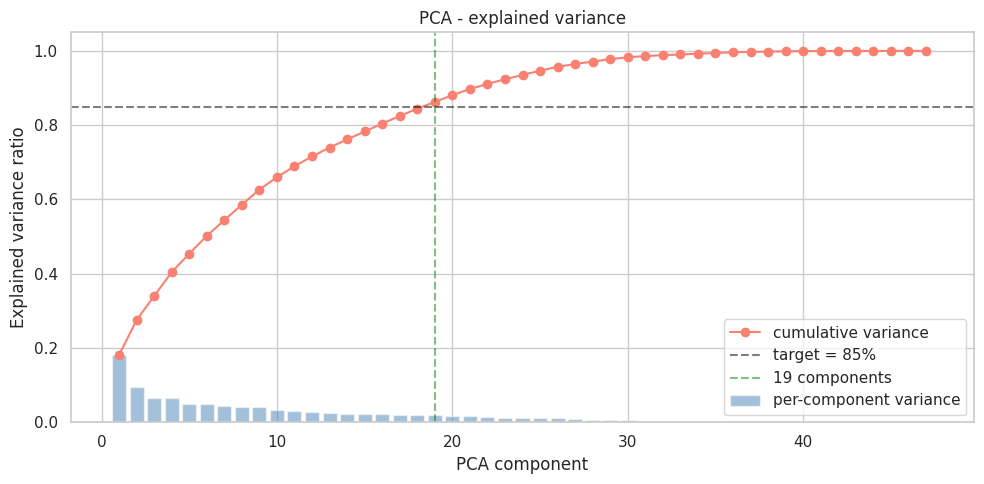

In [6]:
# Plot explained variance curve.
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(var_ratio)+1), var_ratio, alpha=0.5,
       color='steelblue', label='per-component variance')
ax.plot(range(1, len(cum_var)+1), cum_var, marker='o', color='salmon',
        label='cumulative variance')
ax.axhline(PCA_VARIANCE_TARGET, color='black', linestyle='--', alpha=0.5,
           label=f'target = {PCA_VARIANCE_TARGET:.0%}')
ax.axvline(n_components, color='green', linestyle='--', alpha=0.5,
           label=f'{n_components} components')
ax.set_xlabel('PCA component')
ax.set_ylabel('Explained variance ratio')
ax.set_title('PCA - explained variance')
ax.legend()
plt.tight_layout()
save_figure(fig, 'q3_pca_variance.png')
plt.show()
plt.close(fig)


In [7]:
# Refit PCA με τον επιλεγμένο αριθμό components.
pca = make_pca(n_components)
X_pca = pca.fit_transform(X_scaled)
X_pca = np.asarray(X_pca, dtype=np.float32)  # ensure host numpy (cuML returns cupy/cuDF)
print(f'PCA-reduced shape: {X_pca.shape}')

# Επίσης κρατάμε ένα 2-D PCA για visualizations (ίδιο rotation, μόνο τα 2 πρώτα).
X_pca_2d = X_pca[:, :2]

# Save PCA explained variance ledger.
save_results(pd.DataFrame({
    'component'           : range(1, len(var_ratio)+1),
    'explained_variance'  : var_ratio,
    'cumulative_variance' : cum_var,
}), 'q3_pca_variance.csv')


PCA-reduced shape: (500000, 19)


PosixPath('/mnt/d/Documents/GitHub/network-intrusion-detection-ml/outputs/results/q3_pca_variance.csv')

**Τι είδαμε στα δικά μας δεδομένα.** Για το `TARGET_ROWS=500_000` (proportional sampling, 500.000 rows), χρειάζονται **19 components** για να ξεπεράσουμε το 85% - το cumulative variance στους 19 είναι `0.8627`. Η πρώτη component συλλαμβάνει μόλις **~18%** της variance, οπότε δεν υπάρχει ένα κυρίαρχο axis - η information είναι κατανεμημένη σε πολλά components. Συνεπές με τη heuristic του 85%: αρκετή information για clustering χωρίς τον «θόρυβο» των τελευταίων components.

## 3.2 K-Means

**Διαίσθηση.** Επιλέγουμε `k` ως αριθμό clusters. Επανάληψη μέχρι σύγκλιση:
1. **Assignment**: κάθε point ανατίθεται στο πιο κοντινό centroid (ευκλείδεια απόσταση).
2. **Update**: κάθε centroid ξαναϋπολογίζεται ως ο μέσος όρος των points που του ανατέθηκαν.

Συγκλίνει σε local minimum του **inertia** (sum of squared distances των points από το centroid τους).

**Υποθέσεις του K-Means.**
- Clusters είναι περίπου **σφαιρικά** στο feature space.
- Clusters έχουν **παρόμοιο μέγεθος**.
- Γνωρίζουμε εκ των προτέρων το `k`.

**Σε μας.** Οι attack categories δεν είναι σφαιρικές (το BENIGN είναι ~83% του dataset, το Heartbleed είναι 0.0004%). Άρα το K-Means θα έχει δυσκολίες - ειδικά να ξεχωρίσει rare attacks. Είναι όμως καλό baseline.

### Επιλογή k - Elbow + Silhouette για k = 2..15

**Elbow method**: inertia ως συνάρτηση του k· ψάχνουμε τον «αγκώνα». **Silhouette score**: `(b-a)/max(a,b)` ∈ [-1,1], υψηλό = καλύτερα διαχωρισμένα/συνεκτικά clusters.

**Τι δείχνει το plot (proportional 500K).**
- Το **inertia** πέφτει μονοτονικά από `~17.0M` (k=2) σε `~6.79M` (k=15), χωρίς σαφή αγκώνα.
- Το **silhouette** είναι **υψηλότερο στο k=2** (`0.5653`), πέφτει στο k=3 (`0.3156`), ανεβαίνει σταδιακά και φτάνει ένα δευτερεύον τοπικό μέγιστο στο k=15 (`0.4446` στην καμπύλη k-search, από `0.4386` στο k=14). **Το global maximum παραμένει το k=2.**
- **Ερμηνεία:** με proportional sampling το BENIGN είναι ~83% των rows, οπότε η ισχυρότερη γεωμετρική δομή είναι ένας χονδρικός διαχωρισμός **«κανονική κίνηση vs ογκώδεις (volumetric) επιθέσεις»** - γι' αυτό το silhouette ευνοεί k=2. Δεν σημαίνει ότι υπάρχουν μόνο 2 attack types· σημαίνει ότι σε επίπεδο απόστασης η κυρίαρχη διχοτόμηση είναι normal-vs-anomalous. Τρέχουμε **και** k=15 ως reference.

> **Σύγκριση με balanced sampling.** Σε ισορροπημένο δείγμα (ίσος αριθμός ανά κλάση) ο silhouette-best k ανεβαίνει από k=2 (0.565) στο **12** (silhouette 0.481, ≈ #labels=15) - η αντιστοίχιση cluster↔label αναδεικνύεται μόνο όταν εξουδετερώσουμε την κυριαρχία του BENIGN. Στο report παρουσιάζουμε και τα δύο δείγματα (proportional ως main, balanced ως comparison - το αντίστροφο του Q2).

In [8]:
ks = list(range(2, K_MAX + 1))
inertias = []
silhouettes = []

t0 = time.time()
for k in ks:
    km = fit_kmeans_guarded(k, X_pca)
    inertias.append(km.inertia_)
    sample = min(SILHOUETTE_SAMPLE_SIZE, len(X_pca))
    sil = silhouette_score(X_pca, km.labels_, sample_size=sample,
                           random_state=RANDOM_STATE)
    silhouettes.append(sil)
    print(f'  k={k:2d}: inertia={km.inertia_:>14,.0f}  silhouette={sil:.4f}')
print(f'\nElapsed: {time.time()-t0:.1f}s')


  k= 2: inertia=    17,010,070  silhouette=0.5653
  k= 3: inertia=    15,588,896  silhouette=0.3156
  k= 4: inertia=    14,030,755  silhouette=0.3305
  k= 5: inertia=    12,886,667  silhouette=0.3518
  k= 6: inertia=    11,920,724  silhouette=0.3489
  k= 7: inertia=    11,274,339  silhouette=0.3550
  k= 8: inertia=    10,688,473  silhouette=0.3657
  k= 9: inertia=    10,102,642  silhouette=0.3697
  k=10: inertia=     9,371,750  silhouette=0.4078
  k=11: inertia=     8,685,470  silhouette=0.3955
  k=12: inertia=     8,286,556  silhouette=0.4126
  k=13: inertia=     7,515,064  silhouette=0.4251
  k=14: inertia=     7,144,499  silhouette=0.4386
  k=15: inertia=     6,793,120  silhouette=0.4446

Elapsed: 200.7s


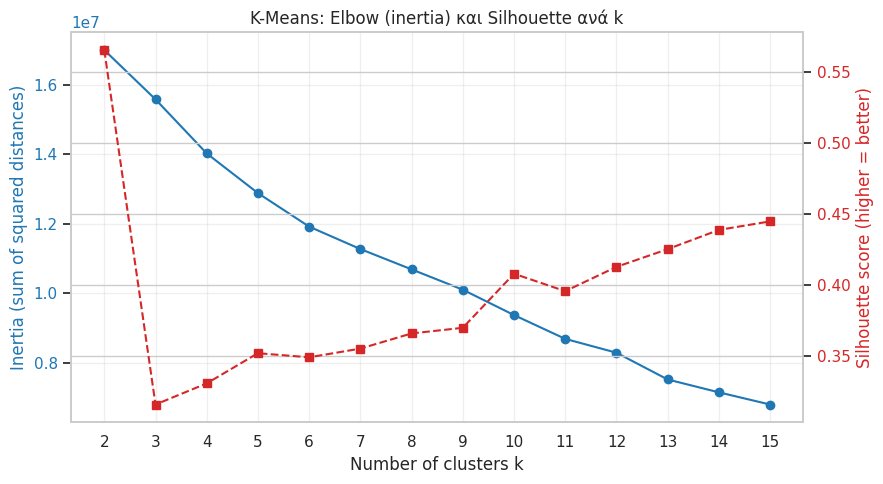

PosixPath('/mnt/d/Documents/GitHub/network-intrusion-detection-ml/outputs/results/q3_kmeans_k_search.csv')

In [9]:
plot_elbow_silhouette(
    ks, inertias, silhouettes,
    title='K-Means: Elbow (inertia) και Silhouette ανά k',
    fname='q3_kmeans_elbow_silhouette.png',
)

save_results(pd.DataFrame({
    'k': ks, 'inertia': inertias, 'silhouette': silhouettes,
}), 'q3_kmeans_k_search.csv')


In [10]:
# Επιλέγουμε το best k βάσει silhouette (ο elbow είναι ποιοτικός κανόνας).
best_k = ks[int(np.argmax(silhouettes))]
print(f'Best k by silhouette: {best_k}  (silhouette={max(silhouettes):.4f})')
print(f'Reference k         : {K_MAX}  (= number of true Labels)')


Best k by silhouette: 2  (silhouette=0.5653)
Reference k         : 15  (= number of true Labels)


### K-Means με best_k και με reference k = #true labels

Η εκφώνηση ζητά K-Means *και* με το best k *και* με `k = 15` (= αριθμός γνωστών attack categories).

**Στη δική μας εκτέλεση (proportional 500K) τα δύο διαφέρουν:**
- **best k=2**: silhouette `0.5653`, Davies-Bouldin `1.4935`.
- **reference k=15**: silhouette `0.4300`, Davies-Bouldin `0.8026`.

Το k=15 έχει **χαμηλότερο** silhouette αλλά **καλύτερο** (χαμηλότερο) Davies-Bouldin - οι δύο μετρικές διαφωνούν, αναμενόμενο σε ασύμμετρα δεδομένα.

**Τι είναι το k=2 split (από το cluster-to-Label heatmap).**
- **c0**: ~89% BENIGN (+ μικρά ποσοστά DDoS/PortScan) → «κανονική / ελαφριά κίνηση».
- **c1**: ~49% DoS Hulk, ~35% BENIGN, ~12% DDoS → «ογκώδεις DoS/DDoS επιθέσεις».

Ακόμη και ο πιο χονδρικός διαχωρισμός είναι **ερμηνεύσιμος** (normal vs volumetric DoS), όχι τυχαίος.

> **Σημαντική διευκρίνιση (interpretation του k=2).** Το ότι κερδίζει το k=2 **δεν** σημαίνει ότι υπάρχουν μόνο 2 τύποι επιθέσεων. Σημαίνει ότι οι 15 κλάσεις **δεν είναι καθαρά διαχωρίσιμες ως 15 γεωμετρικές «μπάλες»** σε αυτόν τον PCA χώρο, υπό proportional (83% BENIGN) δειγματοληψία. Το ισχυρότερο γεωμετρικό σήμα είναι **δυαδικό** (κανονική κίνηση vs flood / ογκώδεις επιθέσεις)· η λεπτότερη 15-way δομή **υπάρχει αλλά είναι μπερδεμένη/επικαλυπτόμενη** - κάτι που είναι από μόνο του ένα ειλικρινές και υπερασπίσιμο εύρημα. (Επιβεβαιώνεται και από την extended αναζήτηση k έως 50: το silhouette πλησιάζει το k=2 μόνο όταν το KMeans σπάει το σύνολο σε δεκάδες μικροσκοπικά clusters outliers - τεχνητή «βελτίωση», όχι πραγματική δομή.)

In [11]:
km_best = fit_kmeans_guarded(best_k, X_pca)
km_ref  = fit_kmeans_guarded(K_MAX,  X_pca)

km_best_metrics = evaluate_clustering(X_pca, km_best.labels_,
                                      sample_size=SILHOUETTE_SAMPLE_SIZE,
                                      seed=RANDOM_STATE)
km_ref_metrics  = evaluate_clustering(X_pca, km_ref.labels_,
                                      sample_size=SILHOUETTE_SAMPLE_SIZE,
                                      seed=RANDOM_STATE)
print(f'K-Means best (k={best_k}): {km_best_metrics}')
print(f'K-Means ref  (k={K_MAX}): {km_ref_metrics}')


K-Means best (k=2): {'n_clusters': 2, 'n_noise': 0, 'silhouette': 0.5653379559516907, 'davies_bouldin': 1.4935029941481612}
K-Means ref  (k=15): {'n_clusters': 15, 'n_noise': 0, 'silhouette': 0.4300139546394348, 'davies_bouldin': 0.8025968518620552}


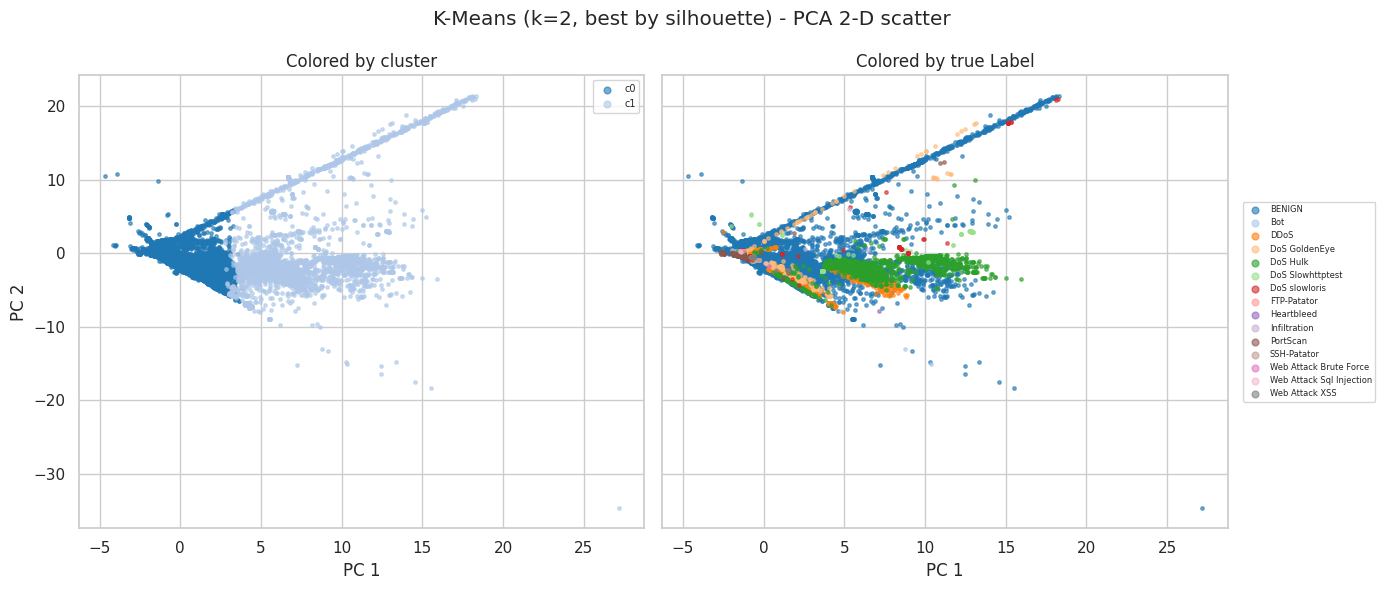

In [12]:
plot_pca_scatter_comparison(
    X_pca_2d, km_best.labels_, y, le.classes_,
    title=f'K-Means (k={best_k}, best by silhouette) - PCA 2-D scatter',
    fname='q3_kmeans_best_scatter.png',
    plot_sample_size=PLOT_SAMPLE_SIZE,
)


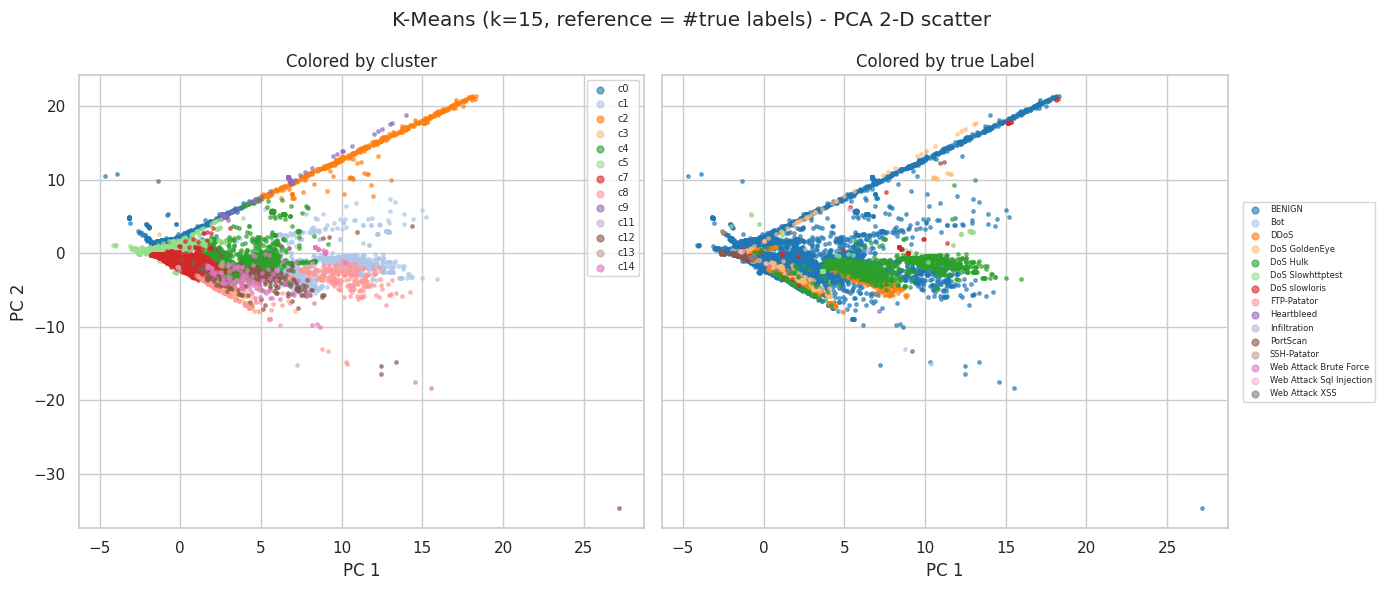

In [13]:
plot_pca_scatter_comparison(
    X_pca_2d, km_ref.labels_, y, le.classes_,
    title=f'K-Means (k={K_MAX}, reference = #true labels) - PCA 2-D scatter',
    fname='q3_kmeans_ref_scatter.png',
    plot_sample_size=PLOT_SAMPLE_SIZE,
)


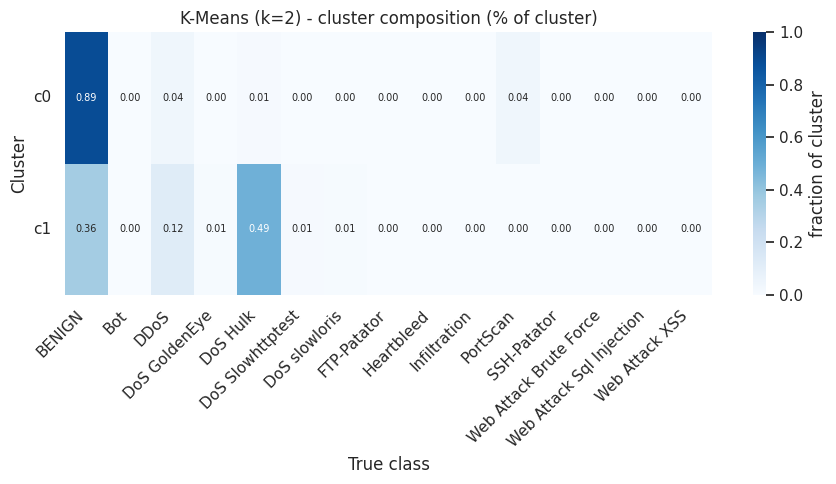

PosixPath('/mnt/d/Documents/GitHub/network-intrusion-detection-ml/outputs/results/q3_kmeans_best_heatmap.csv')

In [14]:
# Cluster-to-Label heatmap για το best k.
ct_km = plot_cluster_label_heatmap(
    km_best.labels_, y, le.classes_,
    title=f'K-Means (k={best_k}) - cluster composition (% of cluster)',
    fname='q3_kmeans_best_heatmap.png',
    normalize='cluster',
)
save_results(ct_km.reset_index().rename(columns={'index': 'cluster'}),
             'q3_kmeans_best_heatmap.csv')


## 3.3 Hierarchical (Agglomerative) Clustering

**Διαίσθηση.** Bottom-up:
1. Ξεκινάμε με κάθε point ως ένα ξεχωριστό cluster.
2. Σε κάθε βήμα, ενώνουμε τα δύο πιο κοντινά clusters.
3. Συνεχίζουμε μέχρι να μείνει ένα cluster που περιέχει όλα.

Παράγει ένα **dendrogram** - ιεραρχικό δέντρο από merges. Για να πάρουμε k clusters, «κόβουμε» το dendrogram στο σωστό height.

**Linkage methods** - πώς ορίζουμε «απόσταση μεταξύ clusters»:
- **single**: ελάχιστη απόσταση μεταξύ points δύο clusters. Φτιάχνει long chain-like clusters (chaining effect).
- **complete**: μέγιστη απόσταση. Φτιάχνει συμπαγή σφαιρικά clusters.
- **average**: μέσος όρος όλων των ζευγών. Συμβιβασμός.
- **ward** (default): minimum-variance criterion. Ενώνει clusters που η συγχώνευσή τους αυξάνει λιγότερο τη συνολική within-cluster variance. Συνήθως καλή επιλογή για σφαιρικά clusters, αλλά στο δικό μας dataset θα δούμε ότι τα **complete/average** παίρνουν το καλύτερο score - αλλά σε k=2 αυτό αντανακλά έναν εύκολο γεωμετρικό διαχωρισμό, όχι αντιστοίχιση με τις κλάσεις (βλ. ενότητα σύγκρισης linkage).

**Computational cost - γιατί υπο-δειγματίζουμε.** Η AgglomerativeClustering απαιτεί τον πλήρη πίνακα αποστάσεων O(n²): για 500K rows αυτό είναι απαγορευτικό σε RAM (O(n²) μνήμη). Παίρνουμε **stratified subsample** με στόχο `HIER_SAMPLE_SIZE // 15 = 200` rows ανά class, αλλά οι rare classes (Heartbleed=11, SQL Injection=21, Infiltration=36) κρατιούνται πλήρως - οπότε το τελικό sample είναι **2.468 rows** (12 κλάσεις × 200 + Heartbleed 11 + SQL Injection 21 + Infiltration 36), όχι ακριβώς `HIER_SAMPLE_SIZE`. Αυτό αρκεί για διαβάσιμο dendrogram και αξιόπιστο linkage comparison.

In [15]:
# Stratified subsample για το hierarchical.
rng_h = np.random.default_rng(RANDOM_STATE)
hier_idx_per_class = []
per_class_quota = max(1, HIER_SAMPLE_SIZE // len(le.classes_))
for cls in np.unique(y):
    cls_idx = np.where(y == cls)[0]
    take = min(len(cls_idx), per_class_quota)
    if take > 0:
        chosen = rng_h.choice(cls_idx, size=take, replace=False)
        hier_idx_per_class.append(chosen)
hier_idx = np.sort(np.concatenate(hier_idx_per_class))

X_hier   = X_pca[hier_idx]
X_hier2d = X_pca_2d[hier_idx]
y_hier   = y[hier_idx]
print(f'Hierarchical sample: {len(y_hier):,} rows')
print('Per-class:')
for cls in np.unique(y_hier):
    print(f'  {le.classes_[cls]:<28s} {(y_hier == cls).sum():>5d}')


Hierarchical sample: 2,468 rows
Per-class:
  BENIGN                         200
  Bot                            200
  DDoS                           200
  DoS GoldenEye                  200
  DoS Hulk                       200
  DoS Slowhttptest               200
  DoS slowloris                  200
  FTP-Patator                    200
  Heartbleed                      11
  Infiltration                    36
  PortScan                       200
  SSH-Patator                    200
  Web Attack Brute Force         200
  Web Attack Sql Injection        21
  Web Attack XSS                 200


### Dendrogram (ward linkage, top 30 merges)

Με 2.253 points, το πλήρες dendrogram θα είχε 2.252 merges. Παρουσιάζουμε μόνο τα **top 30 merges** (κοντά στη ρίζα) - εκεί φαίνεται η μακρο-δομή της ιεραρχίας. Το ύψος κάθε merge δείχνει την απόσταση των δύο clusters που ενώνονται. Οι ετικέτες σε παρενθέσεις `(n)` δείχνουν το μέγεθος κάθε «συμπυκνωμένου» κλάδου.

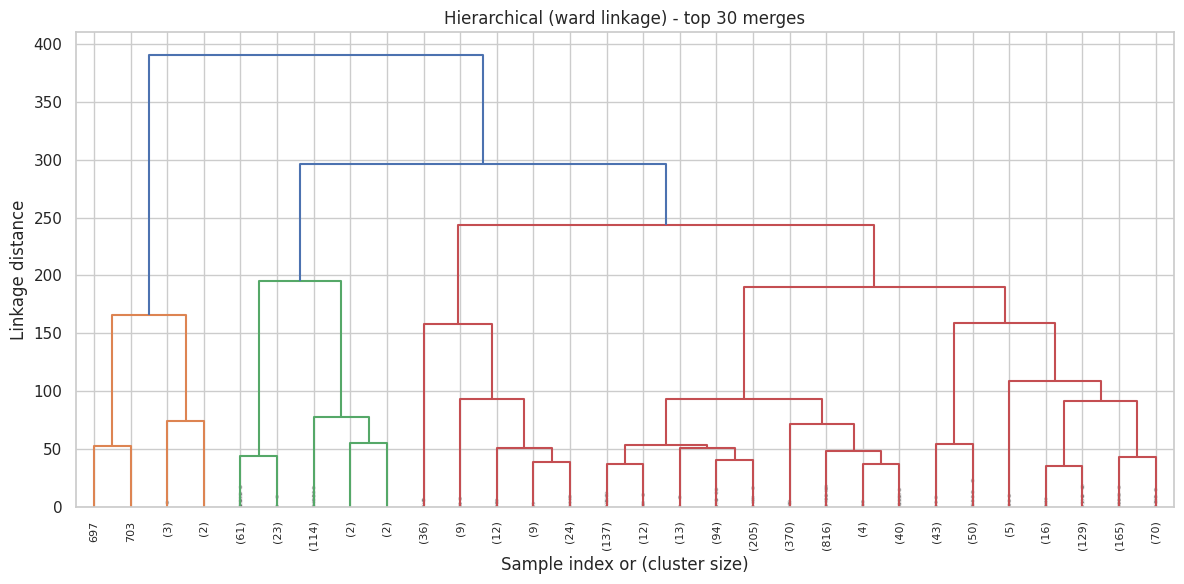

In [16]:
# Φτιάχνουμε linkage matrix με ward (πιο γρήγορο μέσω scipy).
Z = scipy_linkage(X_hier, method='ward')
plot_dendrogram(
    Z, title='Hierarchical (ward linkage) - top 30 merges',
    fname='q3_hier_dendrogram.png', truncate_mode='lastp', p=30,
)


### Σύγκριση linkage methods

Τρέχουμε AgglomerativeClustering με `n_clusters = best_k` (= 2) και τα τρία linkage methods. Αξιολόγηση με Silhouette + Davies-Bouldin σε stratified subsample 2.468 rows.

| Linkage | Silhouette ↑ | Davies-Bouldin ↓ |
|---|---|---|
| ward     | 0,9168 | 0,5021 |
| complete | **0,9201** | **0,2488** |
| average  | **0,9201** | **0,2488** |

Τα **complete** και **average** δίνουν ταυτόσημα top scores (best = complete) - **αλλά προσοχή στην ερμηνεία**: σε k=2 πάνω σε ένα δείγμα με ~83% BENIGN, ο πιο «καθαρός» γεωμετρικά διαχωρισμός απομονώνει ένα πολύ μικρό, πυκνό group από τον υπόλοιπο όγκο. Το ψηλό silhouette (~0.92) αντανακλά κυρίως αυτόν τον εύκολο διαχωρισμό, όχι αντιστοίχιση με τις 15 κλάσεις. Όπως και στο intelex/KMeans degeneracy, ένα ψηλό silhouette score πρέπει να διασταυρώνεται με το **τι περιέχουν** πραγματικά τα clusters (βλ. heatmap).

In [17]:
linkages = ['ward', 'complete', 'average']
hier_results = []
hier_models = {}
for link in linkages:
    t0 = time.time()
    metric = 'euclidean' if link == 'ward' else 'euclidean'
    ac = AgglomerativeClustering(n_clusters=best_k, linkage=link, metric=metric)
    labels_h = ac.fit_predict(X_hier)
    m = evaluate_clustering(X_hier, labels_h,
                            sample_size=SILHOUETTE_SAMPLE_SIZE,
                            seed=RANDOM_STATE)
    elapsed = time.time() - t0
    hier_results.append({'linkage': link, 'k': best_k, **m, 'time_s': round(elapsed, 1)})
    hier_models[link] = labels_h
    print(f'  {link:<10s}: silhouette={m["silhouette"]:.4f}  '
          f'DB={m["davies_bouldin"]:.4f}  ({elapsed:.1f}s)')

hier_df = pd.DataFrame(hier_results)
save_results(hier_df, 'q3_hier_linkage_comparison.csv')
hier_df


  ward      : silhouette=0.9168  DB=0.5021  (0.2s)
  complete  : silhouette=0.9201  DB=0.2488  (0.2s)
  average   : silhouette=0.9201  DB=0.2488  (0.2s)


,linkage,k,n_clusters,n_noise,silhouette,davies_bouldin,time_s
0,ward,2,2,0,0.9168,0.5021,0.2000
1,complete,2,2,0,0.9201,0.2488,0.2000
2,average,2,2,0,0.9201,0.2488,0.2000


Best linkage: complete


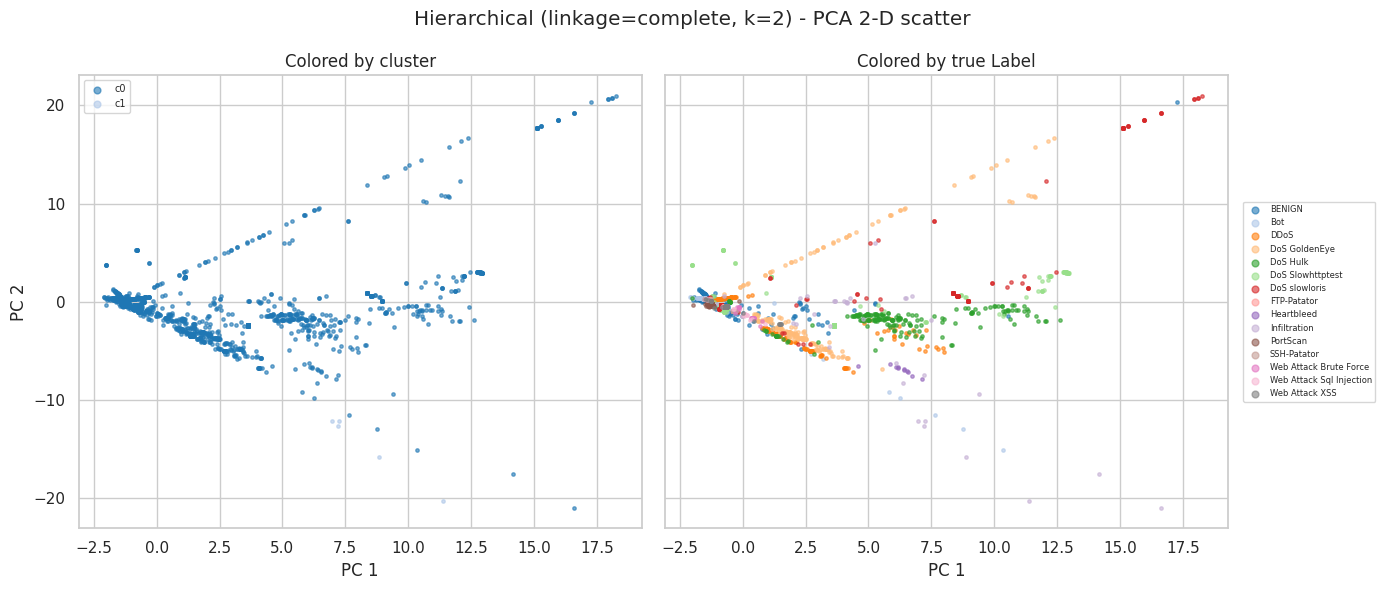

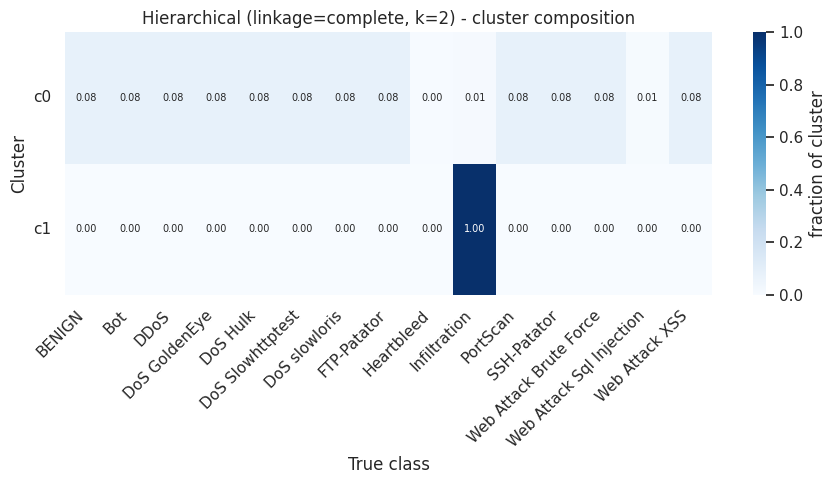

PosixPath('/mnt/d/Documents/GitHub/network-intrusion-detection-ml/outputs/results/q3_hier_best_heatmap.csv')

In [18]:
# Επιλέγουμε το καλύτερο linkage βάσει silhouette.
best_linkage = max(hier_results, key=lambda r: r['silhouette'])['linkage']
print(f'Best linkage: {best_linkage}')
labels_h_best = hier_models[best_linkage]

plot_pca_scatter_comparison(
    X_hier2d, labels_h_best, y_hier, le.classes_,
    title=f'Hierarchical (linkage={best_linkage}, k={best_k}) - PCA 2-D scatter',
    fname='q3_hier_best_scatter.png',
)

ct_h = plot_cluster_label_heatmap(
    labels_h_best, y_hier, le.classes_,
    title=f'Hierarchical (linkage={best_linkage}, k={best_k}) - cluster composition',
    fname='q3_hier_best_heatmap.png', normalize='cluster',
)
save_results(ct_h.reset_index().rename(columns={'index': 'cluster'}),
             'q3_hier_best_heatmap.csv')


## 3.4 DBSCAN

**Διαίσθηση.** Density-based clustering. Δεν χρειάζεται να ορίσουμε εκ των προτέρων το `k`!

**Concepts.**
- **Core point**: ένα point με τουλάχιστον `min_samples` γείτονες μέσα σε ε-ακτίνα.
- **Border point**: όχι core, αλλά μέσα σε ε από κάποιο core.
- **Noise**: όχι core ούτε border.

Δύο core points που είναι μέσα σε ε ο ένας από τον άλλο ανήκουν στο ίδιο cluster. Border points ανατίθενται στο cluster του πιο κοντινού core. Noise points μένουν unassigned (label = -1).

**Πλεονεκτήματα.**
- Δεν χρειάζεται k.
- Ανακαλύπτει clusters **αυθαίρετου σχήματος** (όχι μόνο σφαιρικά - σε αντίθεση με K-Means).
- Ανθεκτικό σε noise/outliers (τα ταξινομεί ως noise).

**Μειονεκτήματα.**
- Ευαίσθητο στις παραμέτρους ε και min_samples.
- Δυσκολεύεται με clusters διαφορετικής **πυκνότητας** (μία ε δεν ταιριάζει σε όλα).
- O(n²) στη χειρότερη περίπτωση (αν δεν χρησιμοποιηθεί spatial index).

**Επιλογή ε - k-distance graph.** Για κάθε point, υπολογίζουμε τη απόσταση προς τον k-οστό πιο κοντινό γείτονα (συνήθως k = `min_samples`). Σχεδιάζουμε αυτές τις αποστάσεις ταξινομημένες αύξουσα. Ο «αγκώνας» της καμπύλης δείχνει ένα καλό ε - κάτω από τον αγκώνα είναι dense regions, πάνω είναι outliers.

**Προ-ειδοποίηση.** Στα δικά μας δεδομένα (500K rows, 19 PCA dims), το dataset έχει **πολύ ανομοιόμορφη πυκνότητα**: BENIGN είναι dense και πολυάριθμο, οι rare attacks είναι dense αλλά πολύ λίγα. Αυτό είναι δύσκολο setting για DBSCAN: θα δούμε είτε πολλά μικρά clusters με μεγάλο noise (μικρό ε), είτε λίγα μεγάλα clusters με λιγότερο noise (μεγάλο ε). Δεν υπάρχει μαγική παράμετρος που να δώσει 15 clusters 1-to-1 με τα γνωστά labels.

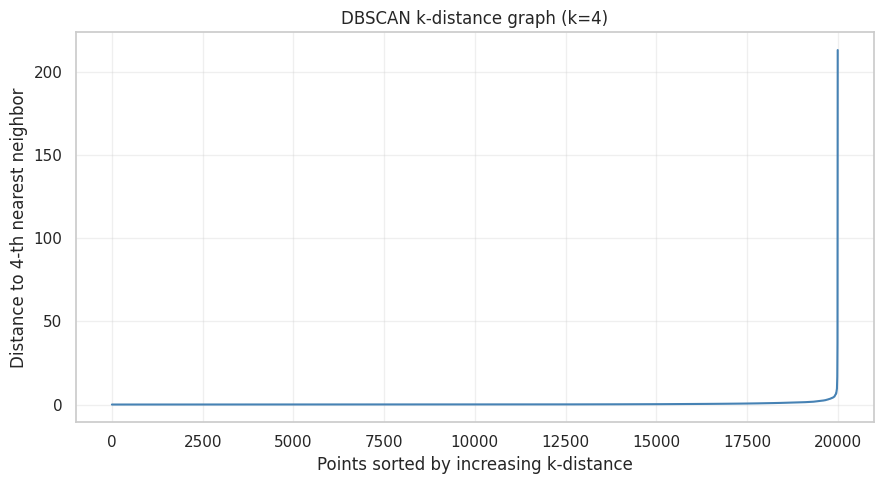

k=4 distance: median=0.0434  p90=0.7789  max=212.9759


In [19]:
# k-distance graph με k=4 (όπως ορίζει η εκφώνηση).
kth = plot_k_distance(
    X_pca, k=4,
    title='DBSCAN k-distance graph (k=4)',
    fname='q3_dbscan_kdistance.png',
    sample_size=20_000, seed=RANDOM_STATE,
)
print(f'k=4 distance: median={np.median(kth):.4f}  '
      f'p90={np.percentile(kth, 90):.4f}  max={np.max(kth):.4f}')


### DBSCAN sweep πάνω σε ε × min_samples

Σύμφωνα με την εκφώνηση: ε ∈ {0.3, 0.5, 0.8, 1.0, 1.5} × min_samples ∈ {5, 10, 20} = 15 combos. Για κάθε valid result (≥2 non-noise clusters) υπολογίζουμε Silhouette + Davies-Bouldin.

Το DBSCAN τρέχει μέσω της `make_dbscan_labels` - **cuML στη GPU** (WSL2 `rapids-gpu` kernel), αλλιώς fallback σε stock sklearn. **Προσοχή στο scaling:** το cuML DBSCAN είναι O(n²) (brute-force neighbor graph). Στο 150K ο sweep ήταν ~2 λεπτά· στο **500K ανέβηκε σε ~23 λεπτά** (~1409s) - 3.3× rows → ~12× χρόνος, καθαρά τετραγωνικό. Η GPU δίνει τεράστιο σταθερό factor (το 150K «φαινόταν» στιγμιαίο), αλλά δεν αλλάζει την κλάση πολυπλοκότητας.

**Τι παρατηρούμε (proportional 500K).**

| Trend | Παρατήρηση |
|---|---|
| Μικρό ε (0.3) | Πάρα πολλά clusters (479-1.526), τεράστιο noise (31K-51K), χαμηλό-μέτριο silhouette (0.04-0.10) |
| Μεσαίο ε (0.5-0.8) | Λιγότερα clusters, μέτριο noise, silhouette κοντά στο 0 ή αρνητικό |
| Μεγάλο ε (1.0) | **Αρνητικό silhouette** (έως -0.34) - επικαλύψεις |
| ε=1.5 | Λίγα clusters (93-225), λίγο noise (2.6K-5.9K)· το **best silhouette του sweep** (0.1051 στο ε=1.5/ms=5) |

Σε σχέση με το 150K run, στο 500K όλα τα silhouette είναι **χαμηλότερα** (η αυξημένη πυκνότητα κάνει τα όρια των clusters πιο θολά) και το best config μετατοπίστηκε από ε=0.3 σε **ε=1.5/ms=5** - αλλά ακόμη και αυτό είναι μόλις 0.105, πολύ κάτω από το K-Means k=2 (0.5653). Σαφές μήνυμα: το DBSCAN δυσκολεύεται σε αυτό το πυκνό, ανομοιόμορφο dataset.

In [20]:
dbscan_results = []
dbscan_models = {}

t_start = time.time()
for eps in DBSCAN_EPS_GRID:
    for ms in DBSCAN_MIN_SAMPLES_GRID:
        t0 = time.time()
        labels_d = make_dbscan_labels(X_pca, eps, ms)
        elapsed = time.time() - t0
        m = evaluate_clustering(X_pca, labels_d,
                                sample_size=SILHOUETTE_SAMPLE_SIZE,
                                seed=RANDOM_STATE)
        row = {'eps': eps, 'min_samples': ms, **m, 'time_s': round(elapsed, 1)}
        dbscan_results.append(row)
        dbscan_models[(eps, ms)] = labels_d
        valid = 'OK' if m['n_clusters'] >= 2 else '--'
        print(f'  ε={eps:>4}  min_samples={ms:>3}  '
              f'clusters={m["n_clusters"]:>4d}  noise={m["n_noise"]:>7,d}  '
              f'sil={m["silhouette"]:.4f}  DB={m["davies_bouldin"]:.4f}  '
              f'({elapsed:.1f}s) {valid}')

print(f'\nTotal DBSCAN sweep time: {time.time()-t_start:.1f}s')
dbscan_df = pd.DataFrame(dbscan_results)
save_results(dbscan_df, 'q3_dbscan_sweep.csv')
dbscan_df


  ε= 0.3  min_samples=  5  clusters=1526  noise= 30,943  sil=0.0716  DB=0.5882  (50.8s) OK
  ε= 0.3  min_samples= 10  clusters= 776  noise= 40,542  sil=0.0416  DB=0.5836  (48.4s) OK
  ε= 0.3  min_samples= 20  clusters= 479  noise= 50,579  sil=0.0988  DB=0.5815  (47.7s) OK
  ε= 0.5  min_samples=  5  clusters=1053  noise= 17,470  sil=-0.0049  DB=0.6576  (74.4s) OK
  ε= 0.5  min_samples= 10  clusters= 606  noise= 24,163  sil=0.0273  DB=0.6625  (73.4s) OK
  ε= 0.5  min_samples= 20  clusters= 347  noise= 32,367  sil=0.0707  DB=0.6599  (70.6s) OK
  ε= 0.8  min_samples=  5  clusters= 731  noise=  8,998  sil=-0.0166  DB=0.7210  (98.5s) OK
  ε= 0.8  min_samples= 10  clusters= 400  noise= 13,241  sil=0.0052  DB=0.7127  (97.0s) OK
  ε= 0.8  min_samples= 20  clusters= 248  noise= 18,655  sil=0.0250  DB=0.7144  (94.1s) OK
  ε= 1.0  min_samples=  5  clusters= 432  noise=  5,957  sil=-0.3374  DB=0.5991  (100.0s) OK
  ε= 1.0  min_samples= 10  clusters= 253  noise=  8,977  sil=-0.3027  DB=0.5855  (98.4

,eps,min_samples,n_clusters,n_noise,silhouette,davies_bouldin,time_s
0,0.3000,5,1526,30943,0.0716,0.5882,50.8000
1,0.3000,10,776,40542,0.0416,0.5836,48.4000
2,0.3000,20,479,50579,0.0988,0.5815,47.7000
3,0.5000,5,1053,17470,-0.0049,0.6576,74.4000
4,0.5000,10,606,24163,0.0273,0.6625,73.4000
5,0.5000,20,347,32367,0.0707,0.6599,70.6000
6,0.8000,5,731,8998,-0.0166,0.7210,98.5000
7,0.8000,10,400,13241,0.0052,0.7127,97.0000
8,0.8000,20,248,18655,0.0250,0.7144,94.1000
9,1.0000,5,432,5957,-0.3374,0.5991,100.0000


In [21]:
# Επιλέγουμε το best DBSCAN config: μέγιστο silhouette ανάμεσα σε όσα παράγουν ≥2 clusters
# και δεν είναι σχεδόν όλα-noise.
valid_db = dbscan_df[
    (dbscan_df['n_clusters'] >= 2)
    & (dbscan_df['n_noise'] < 0.95 * len(y))
].copy()
if len(valid_db):
    best_db_row = valid_db.loc[valid_db['silhouette'].idxmax()]
    best_eps = float(best_db_row['eps'])
    best_ms  = int(best_db_row['min_samples'])
    print(f'Best DBSCAN: ε={best_eps}  min_samples={best_ms}  '
          f'clusters={int(best_db_row["n_clusters"])}  '
          f'silhouette={best_db_row["silhouette"]:.4f}')
    labels_db_best = dbscan_models[(best_eps, best_ms)]
else:
    print('Καμία valid DBSCAN configuration - πέφτουμε σε ε=0.5, min_samples=10 για visualization.')
    best_eps, best_ms = 0.5, 10
    labels_db_best = dbscan_models[(best_eps, best_ms)]


Best DBSCAN: ε=1.5  min_samples=5  clusters=225  silhouette=0.1051


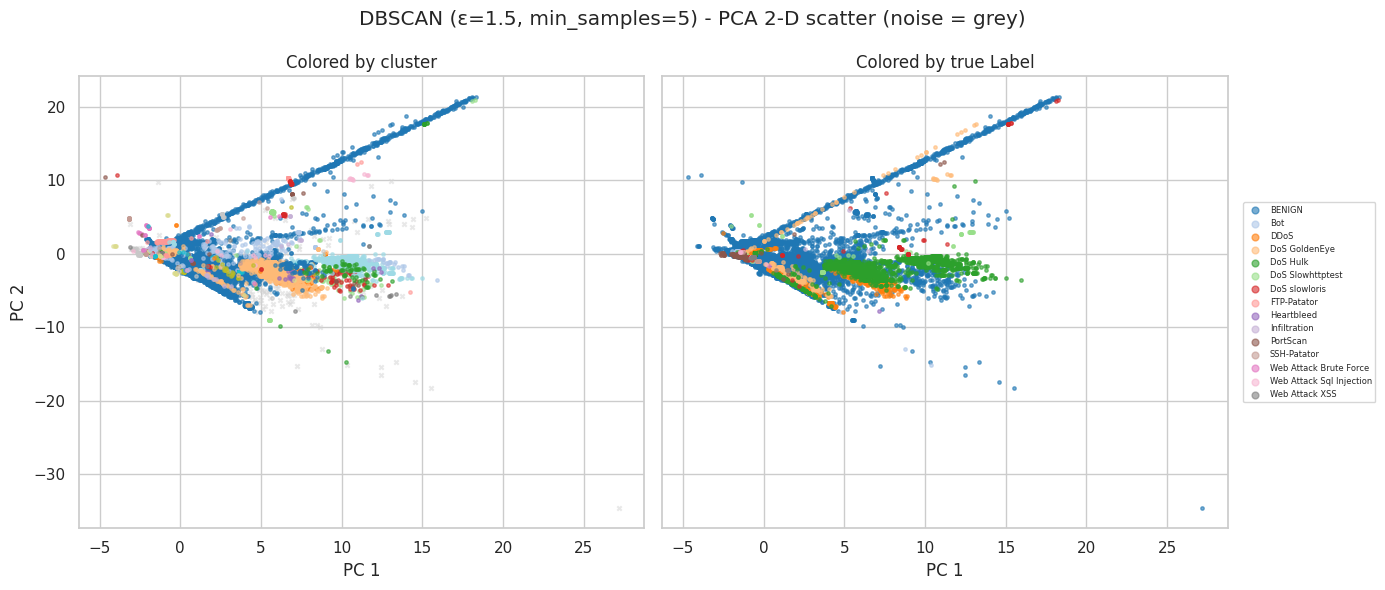

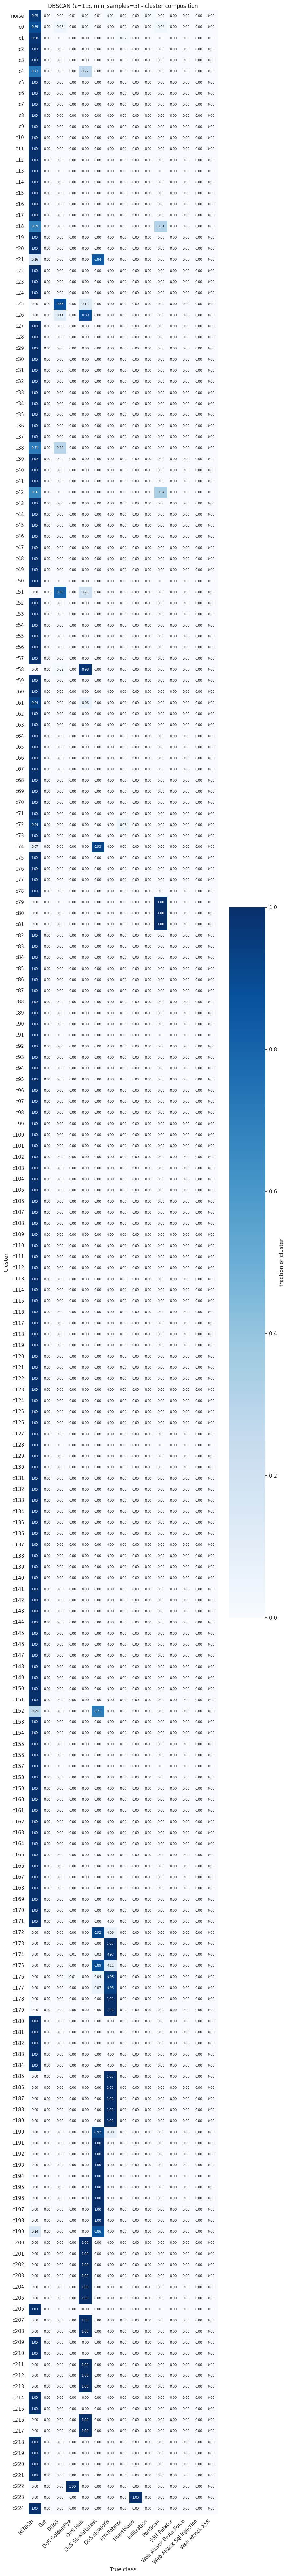

PosixPath('/mnt/d/Documents/GitHub/network-intrusion-detection-ml/outputs/results/q3_dbscan_best_heatmap.csv')

In [22]:
plot_pca_scatter_comparison(
    X_pca_2d, labels_db_best, y, le.classes_,
    title=f'DBSCAN (ε={best_eps}, min_samples={best_ms}) - PCA 2-D scatter (noise = grey)',
    fname='q3_dbscan_best_scatter.png',
)

ct_db = plot_cluster_label_heatmap(
    labels_db_best, y, le.classes_,
    title=f'DBSCAN (ε={best_eps}, min_samples={best_ms}) - cluster composition',
    fname='q3_dbscan_best_heatmap.png', normalize='cluster',
)
save_results(ct_db.reset_index().rename(columns={'index': 'cluster'}),
             'q3_dbscan_best_heatmap.csv')


## 3.5 Συγκριτική ανάλυση

Συγκεντρώνουμε τα best results κάθε αλγορίθμου σε έναν ενιαίο πίνακα και απαντάμε στις ερωτήσεις της εκφώνησης.

In [23]:
comparison_rows = []

comparison_rows.append({
    'algorithm': 'K-Means', 'config': f'k={best_k} (best by silhouette)',
    'n_clusters': km_best_metrics['n_clusters'],
    'n_noise':    km_best_metrics['n_noise'],
    'silhouette': round(km_best_metrics['silhouette'], 4),
    'davies_bouldin': round(km_best_metrics['davies_bouldin'], 4),
    'notes': '',
})
comparison_rows.append({
    'algorithm': 'K-Means', 'config': f'k={K_MAX} (= #true labels)',
    'n_clusters': km_ref_metrics['n_clusters'],
    'n_noise':    km_ref_metrics['n_noise'],
    'silhouette': round(km_ref_metrics['silhouette'], 4),
    'davies_bouldin': round(km_ref_metrics['davies_bouldin'], 4),
    'notes': 'reference run',
})
for r in hier_results:
    comparison_rows.append({
        'algorithm': 'Hierarchical', 'config': f"linkage={r['linkage']}, k={r['k']}",
        'n_clusters': r['n_clusters'], 'n_noise': r['n_noise'],
        'silhouette': round(r['silhouette'], 4),
        'davies_bouldin': round(r['davies_bouldin'], 4),
        'notes': f"trained on {len(y_hier):,} subsample",
    })
for r in dbscan_results:
    if r['n_clusters'] >= 2 and r['n_noise'] < 0.95 * len(y):
        comparison_rows.append({
            'algorithm': 'DBSCAN',
            'config': f"ε={r['eps']}, min_samples={r['min_samples']}",
            'n_clusters': r['n_clusters'], 'n_noise': r['n_noise'],
            'silhouette': round(r['silhouette'], 4),
            'davies_bouldin': round(r['davies_bouldin'], 4),
            'notes': '',
        })

comparison = pd.DataFrame(comparison_rows)
save_results(comparison, 'q3_comparison_table.csv')
comparison


,algorithm,config,n_clusters,n_noise,silhouette,davies_bouldin,notes
0,K-Means,k=2 (best by silhouette),2,0,0.5653,1.4935,
1,K-Means,k=15 (= #true labels),15,0,0.4300,0.8026,reference run
2,Hierarchical,"linkage=ward, k=2",2,0,0.9168,0.5021,"trained on 2,468 subsample"
3,Hierarchical,"linkage=complete, k=2",2,0,0.9201,0.2488,"trained on 2,468 subsample"
4,Hierarchical,"linkage=average, k=2",2,0,0.9201,0.2488,"trained on 2,468 subsample"
5,DBSCAN,"ε=0.3, min_samples=5",1526,30943,0.0716,0.5882,
6,DBSCAN,"ε=0.3, min_samples=10",776,40542,0.0416,0.5836,
7,DBSCAN,"ε=0.3, min_samples=20",479,50579,0.0988,0.5815,
8,DBSCAN,"ε=0.5, min_samples=5",1053,17470,-0.0049,0.6576,
9,DBSCAN,"ε=0.5, min_samples=10",606,24163,0.0273,0.6625,


### Απαντήσεις στις ερωτήσεις της εκφώνησης

*Τιμές από το main run: proportional sampling, `TARGET_ROWS=500_000`, `RANDOM_STATE=42`. KMeans/PCA σε cuML (GPU), Hierarchical σε stock sklearn/scipy (CPU), DBSCAN σε cuML (GPU).*

**1. Αντιστοιχούν τα clusters σε meaningful attack categories;**  
**Μερικώς - και εξαρτάται από την κλίμακα.** Από τα cluster-to-Label heatmaps:
- **K-Means (best k=2):** ερμηνεύσιμος αλλά **χονδρικός** διαχωρισμός - c0 ≈ 89% BENIGN («κανονική κίνηση»), c1 κυριαρχείται από DoS Hulk (~49%) + DDoS (~12%) («ογκώδεις επιθέσεις»). Η ισχυρότερη δομή είναι normal-vs-volumetric-DoS, όχι 15 ξεχωριστές κατηγορίες.
- **DBSCAN (best ε=1.5, min_samples=5):** 225 clusters, αλλά πολλά είναι «καθαρά» pockets - 100% BENIGN, ή σχεδόν καθαρά DoS Hulk - που δείχνει ότι **το BENIGN δεν είναι ομοιογενές**. Αφήνει **2.649 rows (~0.5%) ως noise** σε αυτό το config (στα μικρά ε το noise εκτοξεύεται σε 30K-51K).
- **Rare attacks** (Heartbleed 11, SQL Injection 21, Infiltration 36): δεν σχηματίζουν δικά τους σταθερά clusters - πολύ λίγα για να αναδειχθούν γεωμετρικά μέσα στο proportional δείγμα.

**2. Ποιος αλγόριθμος συλλαμβάνει καλύτερα την true structure;**  
- Με βάση **μόνο** το silhouette, το **Hierarchical** (complete/average 0.9201) φαίνεται καλύτερο - **αλλά παραπλανητικό**: σε k=2 το ψηλό score προκύπτει από έναν εύκολο γεωμετρικό διαχωρισμό σε μικρό subsample, όχι από αντιστοίχιση με τις κλάσεις.
- **K-Means k=2** (silhouette `0.5653`, 0 noise) δίνει τον πιο **έντιμο** χονδρικό διαχωρισμό· το k=15 (`0.4300`) είναι κοντά στον αριθμό labels αλλά το silhouette δεν το ευνοεί.
- **DBSCAN best** (ε=1.5/ms=5): silhouette μόλις `0.1051` - σαφώς το πιο αδύναμο, με density-based προσέγγιση να δυσκολεύεται στο πυκνό dataset.
- **Συμπέρασμα:** κανένας αλγόριθμος δεν ανακτά καθαρά τις 15 κατηγορίες σε αυτό το ρεαλιστικό (83% BENIGN) δείγμα. Η κυρίαρχη δομή είναι «normal vs volumetric DoS» (k=2). Το silhouette πρέπει να διαβάζεται **μαζί** με το περιεχόμενο των clusters.

**3. Τι μπορούμε να ανακαλύψουμε χωρίς labels που δεν φαίνεται με supervised;**  
- **Ετερογένεια του BENIGN.** Το DBSCAN σπάει το BENIGN σε πολλά καθαρά pockets - η «κανονική» κίνηση είναι μείγμα πολλών προφίλ (web/email/bulk), κάτι που ο supervised classifier του Q2 βλέπει ως μία κλάση.
- **Outliers / πιθανές άγνωστες επιθέσεις.** Τα noise points του DBSCAN είναι υποψήφια για zero-day ή ανώμαλα flows που δεν ταιριάζουν σε καμία πυκνή ομάδα.
- **Η κυρίαρχη διχοτόμηση των δεδομένων.** Ο silhouette-best k=2 (normal vs DoS/DDoS) μας λέει ότι το πιο ισχυρό σήμα στα 47 features είναι η διάκριση ογκώδους επίθεσης από κανονική κίνηση - πληροφορία που στο supervised setting «κρύβεται» πίσω από τις 15 ετικέτες.